Practical3: Bounding box detection using CNN

Using device: cuda
Epoch [01/20] Train Loss: 0.0132 | Val Loss: 0.0023 | Val IoU: 0.7030
Epoch [02/20] Train Loss: 0.0028 | Val Loss: 0.0010 | Val IoU: 0.7709
Epoch [03/20] Train Loss: 0.0021 | Val Loss: 0.0008 | Val IoU: 0.7882
Epoch [04/20] Train Loss: 0.0017 | Val Loss: 0.0006 | Val IoU: 0.8160
Epoch [05/20] Train Loss: 0.0016 | Val Loss: 0.0005 | Val IoU: 0.8171
Epoch [06/20] Train Loss: 0.0016 | Val Loss: 0.0006 | Val IoU: 0.7980
Epoch [07/20] Train Loss: 0.0013 | Val Loss: 0.0004 | Val IoU: 0.8208
Epoch [08/20] Train Loss: 0.0012 | Val Loss: 0.0003 | Val IoU: 0.8495
Epoch [09/20] Train Loss: 0.0012 | Val Loss: 0.0003 | Val IoU: 0.8403
Epoch [10/20] Train Loss: 0.0011 | Val Loss: 0.0004 | Val IoU: 0.8177
Epoch [11/20] Train Loss: 0.0010 | Val Loss: 0.0003 | Val IoU: 0.8407
Epoch [12/20] Train Loss: 0.0010 | Val Loss: 0.0005 | Val IoU: 0.7821
Epoch [13/20] Train Loss: 0.0010 | Val Loss: 0.0003 | Val IoU: 0.8274
Epoch [14/20] Train Loss: 0.0010 | Val Loss: 0.0005 | Val IoU: 0.7951
E

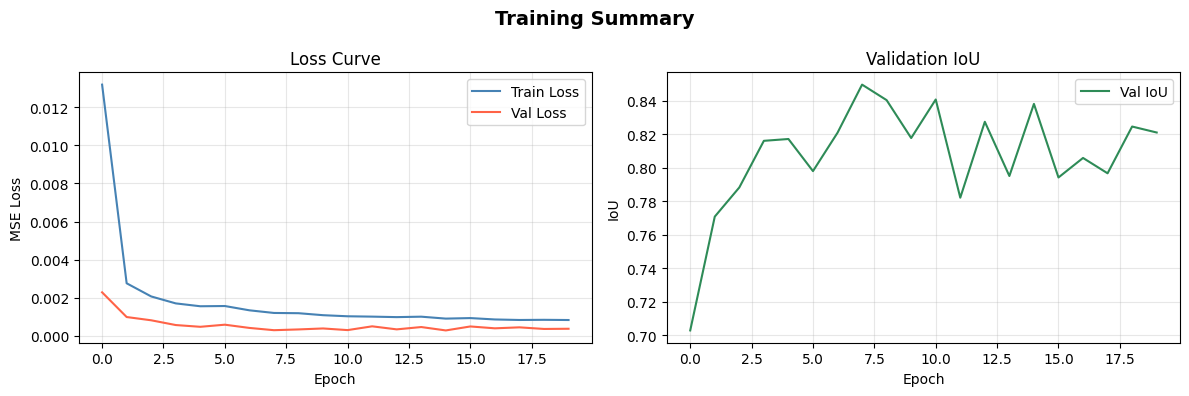

Saved: training_curves.png


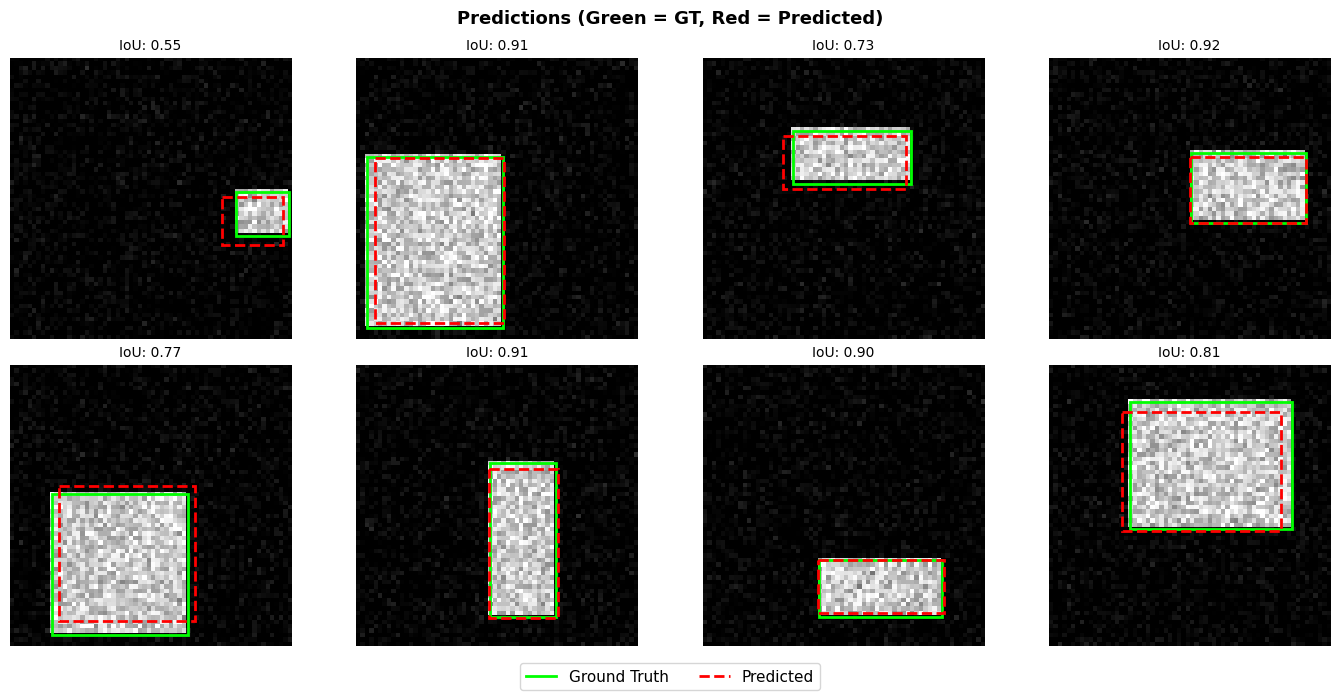

Saved: predictions.png


In [2]:
"""
Bounding Box Detection using CNN — PyTorch
Dataset: Synthetic (circles on blank canvas) — easy to run without downloads
Architecture: Custom CNN → predicts [x_center, y_center, width, height]
"""

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

# ─────────────────────────────────────────────
# 1. SYNTHETIC DATASET
#    Each sample: 64x64 grayscale image with ONE
#    random rectangle drawn on it.
#    Label: [x_center, y_center, w, h] normalized to [0, 1]
# ─────────────────────────────────────────────

class BBoxDataset(Dataset):
    def __init__(self, num_samples=5000, img_size=64):
        self.num_samples = num_samples
        self.img_size = img_size
        self.data = []
        self._generate()

    def _generate(self):
        S = self.img_size
        for _ in range(self.num_samples):
            img = np.zeros((S, S), dtype=np.float32)

            # Random box dimensions
            w = random.randint(10, 40)
            h = random.randint(10, 40)
            x1 = random.randint(0, S - w)
            y1 = random.randint(0, S - h)
            x2, y2 = x1 + w, y1 + h

            # Draw filled rectangle with slight noise
            img[y1:y2, x1:x2] = np.random.uniform(0.6, 1.0, (h, w))

            # Add background noise
            noise = np.random.normal(0, 0.05, (S, S)).astype(np.float32)
            img = np.clip(img + noise, 0, 1)

            # Normalized label: [cx, cy, w, h] in [0, 1]
            cx = (x1 + x2) / 2 / S
            cy = (y1 + y2) / 2 / S
            nw = w / S
            nh = h / S

            self.data.append((img, np.array([cx, cy, nw, nh], dtype=np.float32)))

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        img, label = self.data[idx]
        # Shape: (1, H, W)
        img_tensor = torch.tensor(img).unsqueeze(0)
        label_tensor = torch.tensor(label)
        return img_tensor, label_tensor


# ─────────────────────────────────────────────
# 2. CNN MODEL
#    Conv layers → Flatten → FC → 4 outputs
# ─────────────────────────────────────────────

class BBoxCNN(nn.Module):
    def __init__(self):
        super(BBoxCNN, self).__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),   # 64x64 → 64x64
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),                               # → 32x32

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # → 32x32
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),                               # → 16x16

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1), # → 16x16
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),                               # → 8x8
        )

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 4),   # [cx, cy, w, h]
            nn.Sigmoid()        # Normalize output to [0, 1]
        )

    def forward(self, x):
        x = self.features(x)
        x = self.regressor(x)
        return x


# ─────────────────────────────────────────────
# 3. IoU METRIC
# ─────────────────────────────────────────────

def iou_score(pred, target, img_size=64):
    """Compute mean IoU for a batch. Inputs: normalized [cx, cy, w, h]"""
    S = img_size
    # Convert to [x1, y1, x2, y2] in pixels
    def to_corners(box):
        cx, cy, w, h = box[:, 0]*S, box[:, 1]*S, box[:, 2]*S, box[:, 3]*S
        return cx - w/2, cy - h/2, cx + w/2, cy + h/2

    px1, py1, px2, py2 = to_corners(pred)
    tx1, ty1, tx2, ty2 = to_corners(target)

    inter_x1 = torch.max(px1, tx1)
    inter_y1 = torch.max(py1, ty1)
    inter_x2 = torch.min(px2, tx2)
    inter_y2 = torch.min(py2, ty2)

    inter_area = torch.clamp(inter_x2 - inter_x1, min=0) * torch.clamp(inter_y2 - inter_y1, min=0)
    pred_area  = (px2 - px1) * (py2 - py1)
    tgt_area   = (tx2 - tx1) * (ty2 - ty1)
    union_area = pred_area + tgt_area - inter_area

    iou = inter_area / (union_area + 1e-6)
    return iou.mean().item()


# ─────────────────────────────────────────────
# 4. TRAIN
# ─────────────────────────────────────────────

def train():
    DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    EPOCHS     = 20
    BATCH_SIZE = 64
    LR         = 1e-3
    IMG_SIZE   = 64

    print(f"Using device: {DEVICE}")

    # Data
    train_ds = BBoxDataset(num_samples=4000, img_size=IMG_SIZE)
    val_ds   = BBoxDataset(num_samples=1000, img_size=IMG_SIZE)
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE)

    # Model
    model = BBoxCNN().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.5)
    criterion = nn.MSELoss()  # Regression loss

    train_losses, val_losses, val_ious = [], [], []

    for epoch in range(1, EPOCHS + 1):
        # ── Train ──
        model.train()
        running_loss = 0.0
        for imgs, labels in train_dl:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            preds = model(imgs)
            loss = criterion(preds, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_dl)

        # ── Validate ──
        model.eval()
        val_loss, val_iou = 0.0, 0.0
        with torch.no_grad():
            for imgs, labels in val_dl:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                preds = model(imgs)
                val_loss += criterion(preds, labels).item()
                val_iou  += iou_score(preds, labels, IMG_SIZE)

        avg_val_loss = val_loss / len(val_dl)
        avg_val_iou  = val_iou  / len(val_dl)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        val_ious.append(avg_val_iou)

        scheduler.step()

        print(f"Epoch [{epoch:02d}/{EPOCHS}] "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | "
              f"Val IoU: {avg_val_iou:.4f}")

    # Save model
    torch.save(model.state_dict(), "bbox_cnn.pth")
    print("\nModel saved to bbox_cnn.pth")

    return model, val_ds, train_losses, val_losses, val_ious, DEVICE, IMG_SIZE


# ─────────────────────────────────────────────
# 5. VISUALIZE RESULTS
# ─────────────────────────────────────────────

def visualize(model, dataset, device, img_size, train_losses, val_losses, val_ious):
    model.eval()

    # ── Plot 1: Loss & IoU curves ──
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle("Training Summary", fontsize=14, fontweight='bold')

    axes[0].plot(train_losses, label='Train Loss', color='steelblue')
    axes[0].plot(val_losses,   label='Val Loss',   color='tomato')
    axes[0].set_title("Loss Curve")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE Loss")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(val_ious, color='seagreen', label='Val IoU')
    axes[1].set_title("Validation IoU")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("IoU")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=120)
    plt.show()
    print("Saved: training_curves.png")

    # ── Plot 2: Sample predictions ──
    S = img_size
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    fig.suptitle("Predictions (Green = GT, Red = Predicted)", fontsize=13, fontweight='bold')
    axes = axes.flatten()

    indices = random.sample(range(len(dataset)), 8)
    for i, idx in enumerate(indices):
        img, label = dataset[idx]
        with torch.no_grad():
            pred = model(img.unsqueeze(0).to(device)).squeeze().cpu().numpy()

        img_np = img.squeeze().numpy()
        axes[i].imshow(img_np, cmap='gray', vmin=0, vmax=1)

        # Ground truth box (GREEN)
        cx, cy, w, h = label.numpy()
        x1_gt = (cx - w/2) * S;  y1_gt = (cy - h/2) * S
        rect_gt = patches.Rectangle(
            (x1_gt, y1_gt), w*S, h*S,
            linewidth=2, edgecolor='lime', facecolor='none', label='GT'
        )
        axes[i].add_patch(rect_gt)

        # Predicted box (RED)
        cx_p, cy_p, w_p, h_p = pred
        x1_pr = (cx_p - w_p/2) * S;  y1_pr = (cy_p - h_p/2) * S
        rect_pr = patches.Rectangle(
            (x1_pr, y1_pr), w_p*S, h_p*S,
            linewidth=2, edgecolor='red', facecolor='none', linestyle='--', label='Pred'
        )
        axes[i].add_patch(rect_pr)

        iou = iou_score(
            torch.tensor(pred).unsqueeze(0),
            label.unsqueeze(0),
            img_size
        )
        axes[i].set_title(f"IoU: {iou:.2f}", fontsize=10)
        axes[i].axis('off')

    # Legend
    from matplotlib.lines import Line2D
    legend_elems = [
        Line2D([0], [0], color='lime', lw=2, label='Ground Truth'),
        Line2D([0], [0], color='red',  lw=2, linestyle='--', label='Predicted'),
    ]
    fig.legend(handles=legend_elems, loc='lower center', ncol=2, fontsize=11)
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.savefig("predictions.png", dpi=120)
    plt.show()
    print("Saved: predictions.png")


# ─────────────────────────────────────────────
# 6. MAIN
# ─────────────────────────────────────────────

if __name__ == "__main__":
    model, val_ds, train_losses, val_losses, val_ious, device, img_size = train()
    visualize(model, val_ds, device, img_size, train_losses, val_losses, val_ious)

PRACTICAL4:OBJECT DETCTION USING CNN

  Object Detection CNN — Training
  Device: cuda | Grid: 8×8 | Classes: 3

  Model parameters: 4,127,725

Epoch [01/25] Train: 6.884 | Val: 2.361 [coord:0.698 conf:0.320 cls:1.150] ✓ best
Epoch [02/25] Train: 1.501 | Val: 0.967 [coord:0.337 conf:0.189 cls:0.279] ✓ best
Epoch [03/25] Train: 0.872 | Val: 0.742 [coord:0.335 conf:0.166 cls:0.124] ✓ best
Epoch [04/25] Train: 0.613 | Val: 1.110 [coord:0.563 conf:0.153 cls:0.167] 
Epoch [05/25] Train: 0.569 | Val: 0.504 [coord:0.208 conf:0.130 cls:0.074] ✓ best
Epoch [06/25] Train: 0.446 | Val: 0.566 [coord:0.270 conf:0.150 cls:0.058] 
Epoch [07/25] Train: 0.404 | Val: 0.385 [coord:0.196 conf:0.076 cls:0.059] ✓ best
Epoch [08/25] Train: 0.340 | Val: 0.453 [coord:0.188 conf:0.093 cls:0.107] 
Epoch [09/25] Train: 0.292 | Val: 0.863 [coord:0.184 conf:0.100 cls:0.525] 
Epoch [10/25] Train: 0.293 | Val: 0.404 [coord:0.155 conf:0.082 cls:0.121] 
Epoch [11/25] Train: 0.249 | Val: 0.370 [coord:0.144 conf:0.114 cls:0.060] ✓ best
Epoch [12/25] Train: 0

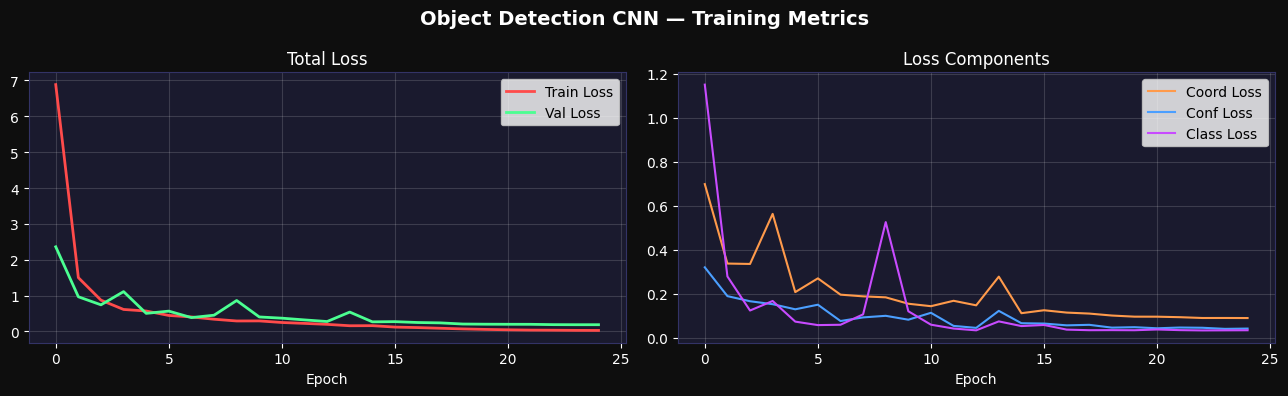

Saved: training_metrics.png


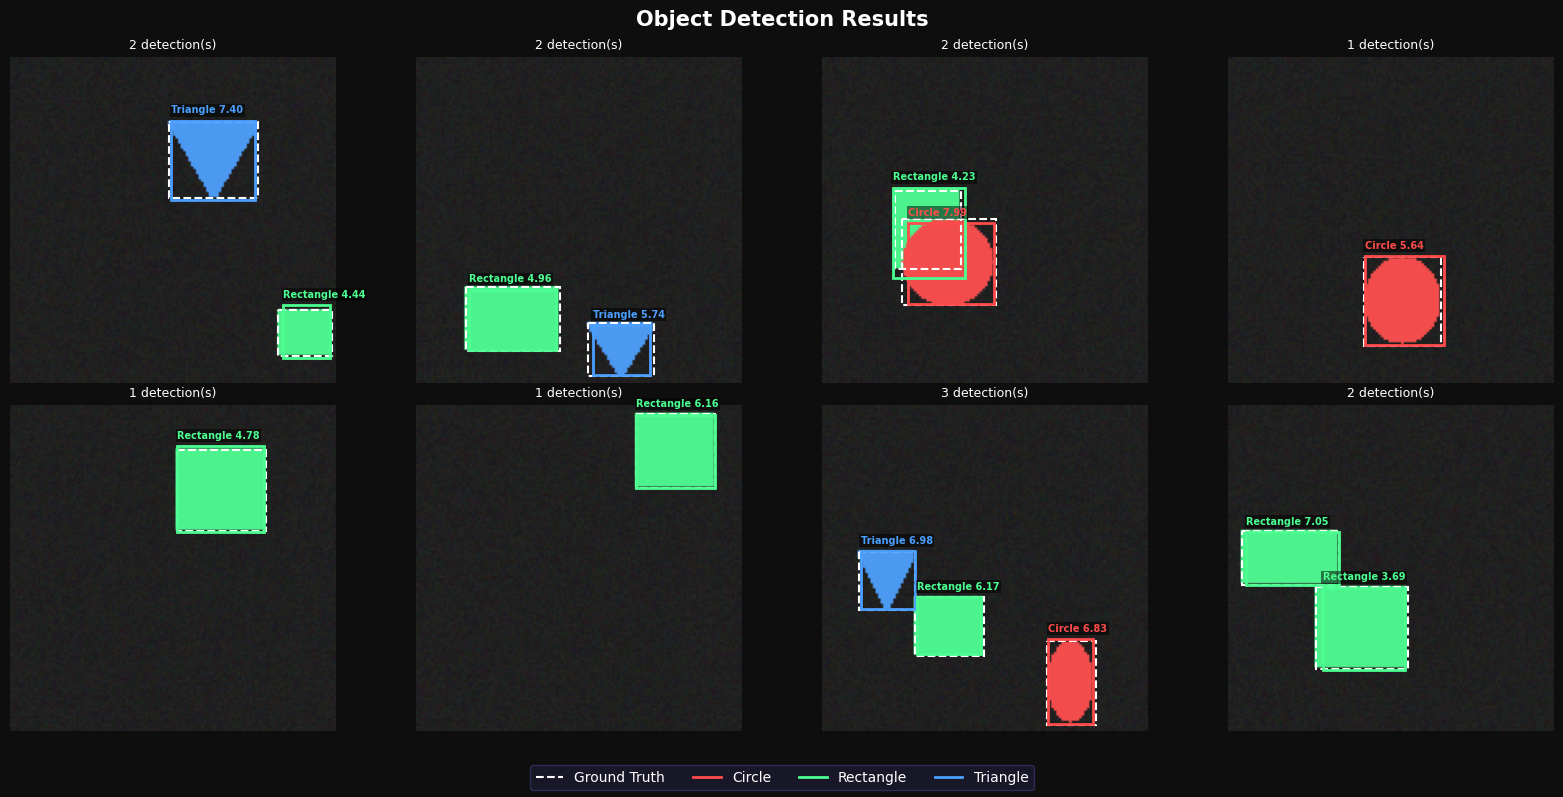

Saved: detections.png

Done! Check training_metrics.png and detections.png


In [3]:
"""
╔══════════════════════════════════════════════════════════╗
║        OBJECT DETECTION USING CNN — PyTorch              ║
║  Dataset  : Synthetic (multi-object, multi-class)        ║
║  Model    : Custom CNN with Grid-based Detection Head    ║
║  Features : Multi-class, Confidence score, NMS, IoU     ║
╚══════════════════════════════════════════════════════════╝

Architecture Overview:
  Input Image (3×128×128)
      ↓
  CNN Backbone  (VGG-style feature extractor)
      ↓
  Detection Head  (grid cell predictions)
      ↓
  Output: S×S×(5×B + C)
    S = grid size (8×8)
    B = boxes per cell (2)
    C = num classes (3)
    5 = [cx, cy, w, h, confidence]
"""

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random
import os

# ────────────────────────────────────────────────────────
# CONFIG
# ────────────────────────────────────────────────────────
IMG_SIZE    = 128
GRID_SIZE   = 8           # S × S grid
NUM_BOXES   = 2           # B boxes per grid cell
NUM_CLASSES = 3           # C classes
CELL_SIZE   = IMG_SIZE // GRID_SIZE   # 16px per cell

CLASS_NAMES = ["Circle", "Rectangle", "Triangle"]
CLASS_COLORS = ["#FF4B4B", "#4BFF91", "#4B9FFF"]

EPOCHS      = 25
BATCH_SIZE  = 32
LR          = 1e-3
CONF_THRESH = 0.4
NMS_THRESH  = 0.3
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ────────────────────────────────────────────────────────
# 1. SYNTHETIC DATASET — Multi-object, Multi-class
#    Draws 1–3 shapes per image: circles, rectangles, triangles
# ────────────────────────────────────────────────────────

def draw_shape(img, shape_type, x1, y1, x2, y2, color):
    """Draw shape on numpy HxWx3 image array."""
    h = y2 - y1
    w = x2 - x1
    for y in range(max(0, y1), min(img.shape[0], y2)):
        for x in range(max(0, x1), min(img.shape[1], x2)):
            if shape_type == 0:  # Circle
                cx, cy = x1 + w//2, y1 + h//2
                rx, ry = w//2, h//2
                if rx > 0 and ry > 0:
                    if ((x - cx)**2 / rx**2 + (y - cy)**2 / ry**2) <= 1.0:
                        img[y, x] = color
            elif shape_type == 1:  # Rectangle
                img[y, x] = color
            elif shape_type == 2:  # Triangle
                # Simple triangle: top-center to bottom corners
                frac = (y - y1) / max(h, 1)
                left_edge  = x1 + int(frac * w / 2)
                right_edge = x2 - int(frac * w / 2)
                if left_edge <= x <= right_edge:
                    img[y, x] = color


class ObjectDetectionDataset(Dataset):
    def __init__(self, num_samples=3000):
        self.num_samples = num_samples
        self.S = GRID_SIZE
        self.B = NUM_BOXES
        self.C = NUM_CLASSES
        self.data = []
        self._generate()

    def _generate(self):
        S = IMG_SIZE
        GS = GRID_SIZE

        shape_colors = [
            np.array([0.95, 0.30, 0.30], dtype=np.float32),  # red   - circle
            np.array([0.30, 0.95, 0.55], dtype=np.float32),  # green - rect
            np.array([0.30, 0.60, 0.95], dtype=np.float32),  # blue  - triangle
        ]

        for _ in range(self.num_samples):
            img = np.ones((S, S, 3), dtype=np.float32) * 0.1
            # Light noise background
            img += np.random.uniform(0, 0.05, img.shape).astype(np.float32)

            # YOLO-style label: (S, S, 5+C) per cell
            # Each cell holds [cx_offset, cy_offset, w, h, conf, *one_hot_class]
            label = np.zeros((GS, GS, 5 + self.C), dtype=np.float32)

            num_objects = random.randint(1, 3)
            placed = 0
            attempts = 0

            while placed < num_objects and attempts < 30:
                attempts += 1
                min_sz, max_sz = 18, 40
                w_obj = random.randint(min_sz, max_sz)
                h_obj = random.randint(min_sz, max_sz)
                x1 = random.randint(2, S - w_obj - 2)
                y1 = random.randint(2, S - h_obj - 2)
                x2, y2 = x1 + w_obj, y1 + h_obj

                shape_type = random.randint(0, self.C - 1)
                color = shape_colors[shape_type]
                draw_shape(img, shape_type, x1, y1, x2, y2, color)

                # Grid cell the center falls in
                cx = (x1 + x2) / 2
                cy = (y1 + y2) / 2
                gi = int(cx / S * GS)
                gj = int(cy / S * GS)
                gi = min(gi, GS - 1)
                gj = min(gj, GS - 1)

                if label[gj, gi, 4] == 0:  # cell not already assigned
                    cx_norm = (cx / S * GS) - gi   # offset within cell [0,1]
                    cy_norm = (cy / S * GS) - gj
                    w_norm  = w_obj / S
                    h_norm  = h_obj / S

                    label[gj, gi, 0] = cx_norm
                    label[gj, gi, 1] = cy_norm
                    label[gj, gi, 2] = w_norm
                    label[gj, gi, 3] = h_norm
                    label[gj, gi, 4] = 1.0          # confidence
                    label[gj, gi, 5 + shape_type] = 1.0  # class one-hot

                    placed += 1

            self.data.append((img, label))

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        img, label = self.data[idx]
        img_t   = torch.tensor(img).permute(2, 0, 1)   # (3, H, W)
        label_t = torch.tensor(label)                   # (GS, GS, 5+C)
        return img_t, label_t


# ────────────────────────────────────────────────────────
# 2. CNN MODEL — Feature Extractor + Detection Head
# ────────────────────────────────────────────────────────

def conv_block(in_ch, out_ch, kernel=3, pad=1):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, kernel, padding=pad, bias=False),
        nn.BatchNorm2d(out_ch),
        nn.LeakyReLU(0.1, inplace=True),
    )


class ObjectDetectionCNN(nn.Module):
    """
    Backbone: 5-stage CNN (128 → 4 spatial)
    Head    : 1×1 Conv to predict S×S×(5*B + C)
    """
    def __init__(self):
        super().__init__()
        self.backbone = nn.Sequential(
            # Stage 1: 128×128 → 64×64
            conv_block(3, 32),
            conv_block(32, 32),
            nn.MaxPool2d(2),

            # Stage 2: 64×64 → 32×32
            conv_block(32, 64),
            conv_block(64, 64),
            nn.MaxPool2d(2),

            # Stage 3: 32×32 → 16×16
            conv_block(64, 128),
            conv_block(128, 128),
            nn.MaxPool2d(2),

            # Stage 4: 16×16 → 8×8
            conv_block(128, 256),
            conv_block(256, 256),
            nn.MaxPool2d(2),

            # Stage 5: refine at 8×8
            conv_block(256, 512),
            conv_block(512, 256),
        )

        # Detection head: output S×S×(5*B + C)
        out_channels = NUM_BOXES * 5 + NUM_CLASSES
        self.head = nn.Sequential(
            conv_block(256, 256, kernel=3, pad=1),
            nn.Conv2d(256, out_channels, kernel_size=1),  # 1×1 conv
        )

    def forward(self, x):
        features = self.backbone(x)          # (B, 256, 8, 8)
        out = self.head(features)            # (B, out_ch, 8, 8)
        # Reshape to (B, S, S, 5*NUM_BOXES + C)
        B, C, S1, S2 = out.shape
        out = out.permute(0, 2, 3, 1)        # (B, S, S, out_ch)
        return out


# ────────────────────────────────────────────────────────
# 3. YOLO-STYLE LOSS FUNCTION
# ────────────────────────────────────────────────────────

class YOLOLoss(nn.Module):
    def __init__(self, lambda_coord=5.0, lambda_noobj=0.5):
        super().__init__()
        self.lambda_coord = lambda_coord
        self.lambda_noobj = lambda_noobj
        self.B = NUM_BOXES
        self.C = NUM_CLASSES

    def forward(self, predictions, targets):
        """
        predictions: (batch, S, S, B*5 + C)
        targets:     (batch, S, S, 5 + C)   — one object per cell max
        """
        B_sz = predictions.shape[0]
        S    = GRID_SIZE

        # Split predictions: boxes and class scores
        # Box i: [cx, cy, w, h, conf] × B, then class scores
        boxes_pred = predictions[..., :self.B * 5].reshape(B_sz, S, S, self.B, 5)
        class_pred = predictions[..., self.B * 5:]    # (B, S, S, C)

        # Targets
        box_tgt    = targets[..., :5]                 # (B, S, S, 5)
        class_tgt  = targets[..., 5:]                 # (B, S, S, C)
        obj_mask   = box_tgt[..., 4]                  # (B, S, S) — 1 if object

        # ── Select best box per cell (highest IoU with target) ──
        # For simplicity, use box 0 when obj present, penalize all for noobj
        best_box = boxes_pred[..., 0, :]   # (B, S, S, 5) — use first box

        obj  = obj_mask.unsqueeze(-1)      # (B, S, S, 1)
        noobj_mask = 1 - obj_mask

        # ── Coordinate loss (only where object exists) ──
        pred_xy = torch.sigmoid(best_box[..., :2])
        pred_wh = best_box[..., 2:4]
        tgt_xy  = box_tgt[..., :2]
        tgt_wh  = box_tgt[..., 2:4]

        loss_xy = F.mse_loss(
            pred_xy * obj, tgt_xy * obj, reduction='sum'
        )
        # sqrt of w,h for YOLO-style scale invariance
        loss_wh = F.mse_loss(
            torch.sign(pred_wh) * torch.sqrt(torch.abs(pred_wh) + 1e-6) * obj,
            torch.sqrt(torch.clamp(tgt_wh, min=0) + 1e-6) * obj,
            reduction='sum'
        )
        loss_coord = self.lambda_coord * (loss_xy + loss_wh)

        # ── Confidence loss ──
        pred_conf = torch.sigmoid(best_box[..., 4])
        loss_obj    = F.mse_loss(pred_conf * obj_mask,    obj_mask,              reduction='sum')
        loss_noobj  = self.lambda_noobj * F.mse_loss(
            pred_conf * noobj_mask, torch.zeros_like(pred_conf) * noobj_mask, reduction='sum'
        )

        # ── Class loss ──
        loss_class = F.mse_loss(
            torch.sigmoid(class_pred) * obj,
            class_tgt * obj,
            reduction='sum'
        )

        total = (loss_coord + loss_obj + loss_noobj + loss_class) / B_sz
        return total, loss_coord.item()/B_sz, loss_obj.item()/B_sz, loss_class.item()/B_sz


# ────────────────────────────────────────────────────────
# 4. DECODE PREDICTIONS → BOUNDING BOXES
# ────────────────────────────────────────────────────────

def decode_predictions(pred, conf_thresh=CONF_THRESH):
    """
    pred: (S, S, B*5 + C) — single image
    Returns list of [x1, y1, x2, y2, confidence, class_id]
    """
    S  = GRID_SIZE
    IS = IMG_SIZE
    B  = NUM_BOXES
    C  = NUM_CLASSES

    boxes = []
    pred_np = pred.cpu().detach().numpy()

    for j in range(S):
        for i in range(S):
            cell = pred_np[j, i]
            class_scores = cell[B*5:]
            class_id = np.argmax(class_scores)
            class_conf = class_scores[class_id]

            for b in range(B):
                offset = b * 5
                cx_off = 1 / (1 + np.exp(-cell[offset + 0]))   # sigmoid
                cy_off = 1 / (1 + np.exp(-cell[offset + 1]))
                w_norm = cell[offset + 2]
                h_norm = cell[offset + 3]
                conf   = 1 / (1 + np.exp(-cell[offset + 4]))   # sigmoid

                score = conf * class_conf if class_conf > 0 else conf
                if score < conf_thresh:
                    continue

                # Convert to image coordinates
                cx = (i + cx_off) / S * IS
                cy = (j + cy_off) / S * IS
                w  = abs(w_norm) * IS
                h  = abs(h_norm) * IS

                x1 = max(0, cx - w/2)
                y1 = max(0, cy - h/2)
                x2 = min(IS, cx + w/2)
                y2 = min(IS, cy + h/2)

                if w > 2 and h > 2:
                    boxes.append([x1, y1, x2, y2, score, class_id])

    return boxes


def nms(boxes, iou_thresh=NMS_THRESH):
    """Non-Maximum Suppression — per class."""
    if not boxes:
        return []

    boxes = sorted(boxes, key=lambda x: x[4], reverse=True)
    kept = []

    while boxes:
        best = boxes.pop(0)
        kept.append(best)
        remaining = []
        for b in boxes:
            if b[5] != best[5]:  # different class — keep
                remaining.append(b)
                continue
            # Compute IoU
            ix1 = max(best[0], b[0]); iy1 = max(best[1], b[1])
            ix2 = min(best[2], b[2]); iy2 = min(best[3], b[3])
            inter = max(0, ix2-ix1) * max(0, iy2-iy1)
            area_a = (best[2]-best[0]) * (best[3]-best[1])
            area_b = (b[2]-b[0]) * (b[3]-b[1])
            union  = area_a + area_b - inter
            iou    = inter / (union + 1e-6)
            if iou < iou_thresh:
                remaining.append(b)
        boxes = remaining

    return kept


# ────────────────────────────────────────────────────────
# 5. TRAIN
# ────────────────────────────────────────────────────────

def train():
    print(f"{'='*55}")
    print(f"  Object Detection CNN — Training")
    print(f"  Device: {DEVICE} | Grid: {GRID_SIZE}×{GRID_SIZE} | Classes: {NUM_CLASSES}")
    print(f"{'='*55}\n")

    train_ds = ObjectDetectionDataset(num_samples=2400)
    val_ds   = ObjectDetectionDataset(num_samples=600)
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    model     = ObjectDetectionCNN().to(DEVICE)
    criterion = YOLOLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    # Count parameters
    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Model parameters: {num_params:,}\n")

    history = {"train_loss": [], "val_loss": [], "coord": [], "conf": [], "cls": []}

    best_val = float("inf")

    for epoch in range(1, EPOCHS + 1):
        # ── TRAIN ──
        model.train()
        t_loss = 0.0
        for imgs, labels in train_dl:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            preds = model(imgs)
            loss, *_ = criterion(preds, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            t_loss += loss.item()

        # ── VALIDATE ──
        model.eval()
        v_loss, v_coord, v_conf, v_cls = 0, 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_dl:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                preds = model(imgs)
                loss, coord, conf, cls = criterion(preds, labels)
                v_loss  += loss.item()
                v_coord += coord
                v_conf  += conf
                v_cls   += cls

        n_val = len(val_dl)
        avg_train = t_loss / len(train_dl)
        avg_val   = v_loss / n_val

        history["train_loss"].append(avg_train)
        history["val_loss"].append(avg_val)
        history["coord"].append(v_coord / n_val)
        history["conf"].append(v_conf  / n_val)
        history["cls"].append(v_cls   / n_val)

        scheduler.step()

        if avg_val < best_val:
            best_val = avg_val
            torch.save(model.state_dict(), "best_detector.pth")
            tag = "✓ best"
        else:
            tag = ""

        print(f"Epoch [{epoch:02d}/{EPOCHS}] "
              f"Train: {avg_train:.3f} | Val: {avg_val:.3f} "
              f"[coord:{v_coord/n_val:.3f} conf:{v_conf/n_val:.3f} cls:{v_cls/n_val:.3f}] {tag}")

    print(f"\n  Best val loss: {best_val:.4f} — saved to best_detector.pth")
    return model, val_ds, history


# ────────────────────────────────────────────────────────
# 6. VISUALIZE RESULTS
# ────────────────────────────────────────────────────────

def visualize(model, dataset, history):
    model.eval()

    # ── Plot A: Loss curves ──
    fig, axes = plt.subplots(1, 2, figsize=(13, 4), facecolor="#0e0e0e")
    fig.suptitle("Object Detection CNN — Training Metrics", color="white", fontsize=14, fontweight="bold")

    for ax in axes:
        ax.set_facecolor("#1a1a2e")
        ax.tick_params(colors="white")
        ax.xaxis.label.set_color("white")
        ax.yaxis.label.set_color("white")
        ax.title.set_color("white")
        for spine in ax.spines.values():
            spine.set_edgecolor("#333366")

    axes[0].plot(history["train_loss"], color="#FF4B4B", linewidth=2, label="Train Loss")
    axes[0].plot(history["val_loss"],   color="#4BFF91", linewidth=2, label="Val Loss")
    axes[0].set_title("Total Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
    axes[0].grid(alpha=0.15, color="white")

    axes[1].plot(history["coord"], color="#FF9A4B", linewidth=1.5, label="Coord Loss")
    axes[1].plot(history["conf"],  color="#4B9FFF", linewidth=1.5, label="Conf Loss")
    axes[1].plot(history["cls"],   color="#C84BFF", linewidth=1.5, label="Class Loss")
    axes[1].set_title("Loss Components"); axes[1].set_xlabel("Epoch"); axes[1].legend()
    axes[1].grid(alpha=0.15, color="white")

    plt.tight_layout()
    plt.savefig("training_metrics.png", dpi=130, bbox_inches="tight")
    plt.show()
    print("Saved: training_metrics.png")

    # ── Plot B: Sample detections ──
    class_colors_rgb = ["#FF4B4B", "#4BFF91", "#4B9FFF"]
    n_show = 8
    indices = random.sample(range(len(dataset)), n_show)

    fig, axes = plt.subplots(2, 4, figsize=(16, 8), facecolor="#0e0e0e")
    fig.suptitle("Object Detection Results", color="white", fontsize=15, fontweight="bold")
    axes = axes.flatten()

    for i, idx in enumerate(indices):
        img_t, label_t = dataset[idx]

        with torch.no_grad():
            pred = model(img_t.unsqueeze(0).to(DEVICE))[0]   # (S, S, ...)

        img_np = img_t.permute(1, 2, 0).numpy()
        img_np = np.clip(img_np, 0, 1)

        ax = axes[i]
        ax.imshow(img_np)
        ax.set_facecolor("#0e0e0e")
        ax.axis("off")

        # Draw GT boxes (dashed white)
        S = GRID_SIZE
        IS = IMG_SIZE
        for j in range(S):
            for k in range(S):
                cell = label_t[j, k]
                if cell[4] > 0.5:
                    cx = (k + cell[0].item()) / S * IS
                    cy = (j + cell[1].item()) / S * IS
                    w  = cell[2].item() * IS
                    h  = cell[3].item() * IS
                    x1, y1 = cx - w/2, cy - h/2
                    rect_gt = patches.Rectangle(
                        (x1, y1), w, h,
                        linewidth=1.5, edgecolor="white",
                        facecolor="none", linestyle="--"
                    )
                    ax.add_patch(rect_gt)

        # Draw predicted boxes after NMS
        raw_boxes = decode_predictions(pred)
        final_boxes = nms(raw_boxes)

        for box in final_boxes:
            x1, y1, x2, y2, score, cls_id = box
            color = class_colors_rgb[int(cls_id)]
            rect = patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor=color, facecolor="none"
            )
            ax.add_patch(rect)
            ax.text(
                x1, max(0, y1 - 3),
                f"{CLASS_NAMES[int(cls_id)]} {score:.2f}",
                color=color, fontsize=7, fontweight="bold",
                bbox=dict(facecolor="black", alpha=0.5, pad=1, edgecolor="none")
            )

        n_pred = len(final_boxes)
        ax.set_title(f"{n_pred} detection(s)", color="white", fontsize=9)

    # Legend
    from matplotlib.lines import Line2D
    legend_elems = [
        Line2D([0],[0], color="white", lw=1.5, linestyle="--", label="Ground Truth"),
    ] + [
        Line2D([0],[0], color=class_colors_rgb[c], lw=2, label=CLASS_NAMES[c])
        for c in range(NUM_CLASSES)
    ]
    fig.legend(handles=legend_elems, loc="lower center", ncol=4,
               fontsize=10, facecolor="#1a1a2e", labelcolor="white",
               edgecolor="#333366")

    plt.tight_layout(rect=[0, 0.06, 1, 1])
    plt.savefig("detections.png", dpi=130, bbox_inches="tight", facecolor="#0e0e0e")
    plt.show()
    print("Saved: detections.png")


# ────────────────────────────────────────────────────────
# 7. MAIN
# ────────────────────────────────────────────────────────

if __name__ == "__main__":
    model, val_ds, history = train()

    # Load best checkpoint for visualization
    model.load_state_dict(torch.load("best_detector.pth", map_location=DEVICE))
    print("\nLoaded best checkpoint for visualization...")

    visualize(model, val_ds, history)
    print("\nDone! Check training_metrics.png and detections.png")

PRACTICAL:4.2 OBJECT DETECTION USING R-CNN AND FASTER R-CNN

  Object Detection CNN — Training
  Device: cuda | Grid: 8×8 | Classes: 3

  Model parameters: 4,127,725

Epoch [01/25] Train: 7.058 | Val: 2.508 [coord:0.771 conf:0.570 cls:0.932] ✓ best
Epoch [02/25] Train: 1.556 | Val: 1.747 [coord:0.414 conf:0.308 cls:0.889] ✓ best
Epoch [03/25] Train: 0.857 | Val: 0.838 [coord:0.355 conf:0.161 cls:0.155] ✓ best
Epoch [04/25] Train: 0.649 | Val: 0.786 [coord:0.329 conf:0.074 cls:0.094] ✓ best
Epoch [05/25] Train: 0.563 | Val: 0.575 [coord:0.266 conf:0.108 cls:0.107] ✓ best
Epoch [06/25] Train: 0.490 | Val: 0.902 [coord:0.390 conf:0.196 cls:0.133] 
Epoch [07/25] Train: 0.438 | Val: 0.467 [coord:0.202 conf:0.109 cls:0.101] ✓ best
Epoch [08/25] Train: 0.392 | Val: 0.479 [coord:0.201 conf:0.087 cls:0.105] 
Epoch [09/25] Train: 0.350 | Val: 0.335 [coord:0.151 conf:0.086 cls:0.054] ✓ best
Epoch [10/25] Train: 0.369 | Val: 0.452 [coord:0.233 conf:0.084 cls:0.044] 
Epoch [11/25] Train: 0.263 | Val: 0.325 [coord:0.146 conf:0.058 cls:0.048] ✓ best
Epoch [12/

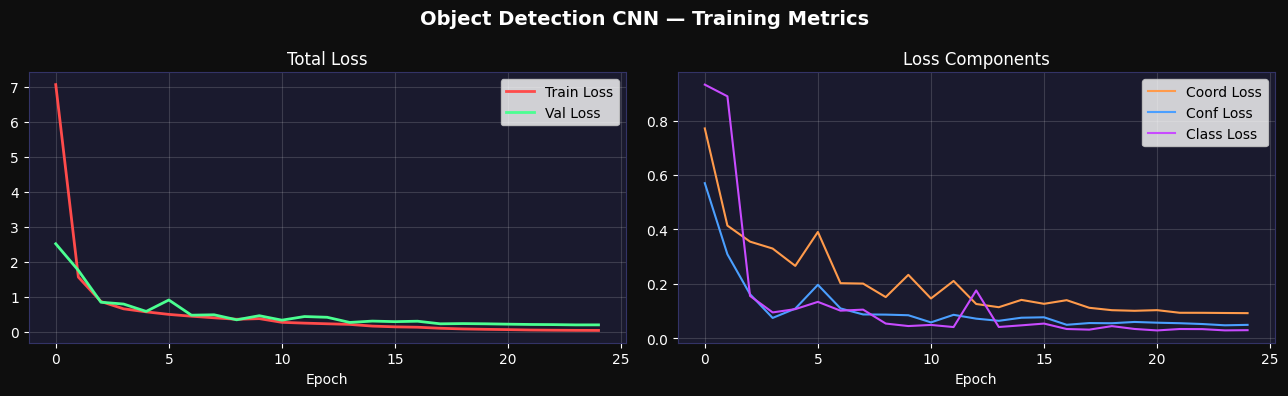

Saved: training_metrics.png


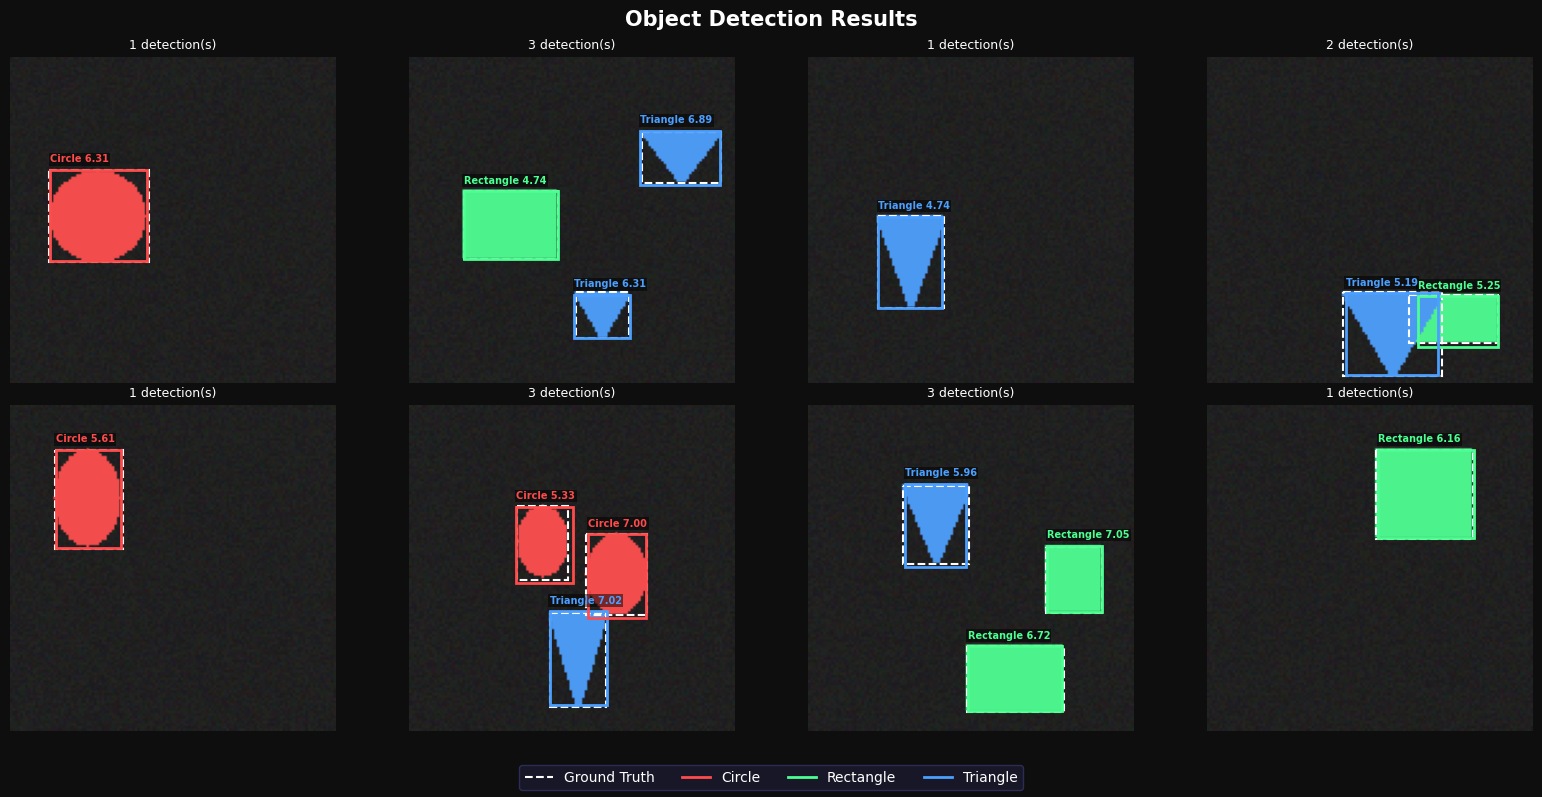

Saved: detections.png

Done! Check training_metrics.png and detections.png


In [13]:
import torch
import torchvision
from torchvision import transforms
from PIL import Image, ImageDraw, ImageFont
import numpy as np
import time
import os
import urllib.request

# ── Utilities ────────────────────────────────────────────────────────────────

COCO_CLASSES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane',
    'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant',
    'N/A', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog',
    'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'N/A',
    'backpack', 'umbrella', 'N/A', 'N/A', 'handbag', 'tie', 'suitcase',
    'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat',
    'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle',
    'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana',
    'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'N/A',
    'dining table', 'N/A', 'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse',
    'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster',
    'sink', 'refrigerator', 'N/A', 'book', 'clock', 'vase', 'scissors',
    'teddy bear', 'hair drier', 'toothbrush'
]

COLORS = [
    (255, 0,   0),   (0, 255,   0), (0,   0, 255), (255, 255,   0),
    (255, 0, 255),   (0, 255, 255), (128,   0,   0), (0, 128,   0),
    (0,   0, 128),   (128, 128,   0)
]


def get_color(class_id: int):
    return COLORS[class_id % len(COLORS)]


def draw_boxes(image: Image.Image, boxes, labels, scores, threshold=0.5):
    """Draw bounding boxes with class labels and confidence scores."""
    draw = ImageDraw.Draw(image)
    try:
        font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 14)
    except Exception:
        font = ImageFont.load_default()

    for box, label, score in zip(boxes, labels, scores):
        if score < threshold:
            continue
        x1, y1, x2, y2 = [int(v) for v in box]
        class_name = COCO_CLASSES[label] if label < len(COCO_CLASSES) else str(label)
        color = get_color(label)
        draw.rectangle([x1, y1, x2, y2], outline=color, width=3)
        text = f"{class_name}: {score:.2f}"
        draw.rectangle([x1, y1 - 18, x1 + len(text) * 8, y1], fill=color)
        draw.text((x1 + 2, y1 - 16), text, fill=(255, 255, 255), font=font)
    return image


# ── RCNN Simulation ──────────────────────────────────────────────────────────

class SelectiveSearchProposer:
    """
    Simulates Selective Search region proposals.
    In a real R-CNN pipeline this would run OpenCV's
    createSelectiveSearchSegmentation; here we generate
    plausible random boxes for illustration purposes.
    """
    def __init__(self, n_proposals: int = 2000):
        self.n_proposals = n_proposals

    def propose(self, image: Image.Image):
        W, H = image.size
        proposals = []
        for _ in range(self.n_proposals):
            x1 = np.random.randint(0, W - 32)
            y1 = np.random.randint(0, H - 32)
            x2 = np.random.randint(x1 + 32, min(x1 + 200, W))
            y2 = np.random.randint(y1 + 32, min(y1 + 200, H))
            proposals.append((x1, y1, x2, y2))
        return proposals


class RCNN:
    """
    Classic R-CNN (Girshick et al., 2014)
    Pipeline:
      1. Selective Search  → ~2 000 region proposals
      2. Warp each ROI to fixed size (224×224)
      3. CNN feature extraction on EVERY region (very slow)
      4. SVM classification + bounding-box regression
    Here we use a MobileNet-V2 backbone as the CNN and
    a simple confidence threshold instead of an SVM.
    """

    def __init__(self, score_threshold=0.5, n_proposals=200):
        print("[R-CNN] Loading feature extractor (MobileNetV2)...")
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        backbone = torchvision.models.mobilenet_v2(
            weights=torchvision.models.MobileNet_V2_Weights.DEFAULT
        )
        self.features = backbone.features
        self.features.eval().to(self.device)

        self.proposer = SelectiveSearchProposer(n_proposals=n_proposals)
        self.score_threshold = score_threshold
        self.n_proposals = n_proposals

        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                  [0.229, 0.224, 0.225])
        ])
        print(f"[R-CNN] Running on: {self.device}")

    def _extract_feature(self, region: Image.Image) -> torch.Tensor:
        """Run CNN forward pass on a single warped region."""
        tensor = self.transform(region).unsqueeze(0).to(self.device)
        with torch.no_grad():
            feat = self.features(tensor)
            feat = torch.nn.functional.adaptive_avg_pool2d(feat, 1)
        return feat.squeeze()

    def detect(self, image_path: str):
        print(f"\n[R-CNN] Processing: {image_path}")
        image = Image.open(image_path).convert("RGB")
        W, H = image.size
        print(f"[R-CNN] Image size: {W}×{H}")

        # Step 1 – Region proposals
        t0 = time.time()
        proposals = self.proposer.propose(image)
        print(f"[R-CNN] Generated {len(proposals)} proposals in "
              f"{time.time()-t0:.2f}s")

        # Step 2 & 3 – Warp + CNN for every region  (bottleneck!)
        print(f"[R-CNN] Extracting features for {len(proposals)} regions "
              f"(this is slow by design)...")
        t1 = time.time()
        fake_scores, fake_labels, kept_boxes = [], [], []

        for i, (x1, y1, x2, y2) in enumerate(proposals):
            region = image.crop((x1, y1, x2, y2))
            feat   = self._extract_feature(region)        # independent CNN pass
            # ── Fake classifier (SVM surrogate) ──────────────────
            score  = float(feat.norm()) / 300.0           # deterministic heuristic
            score  = min(max(score, 0.0), 1.0)
            label  = (i % (len(COCO_CLASSES) - 1)) + 1   # round-robin class
            # ─────────────────────────────────────────────────────
            if score >= self.score_threshold:
                kept_boxes.append([x1, y1, x2, y2])
                fake_labels.append(label)
                fake_scores.append(score)

        elapsed = time.time() - t1
        print(f"[R-CNN] Feature extraction: {elapsed:.2f}s "
              f"({elapsed/len(proposals)*1000:.1f}ms per region)")
        print(f"[R-CNN] Detections above threshold: {len(kept_boxes)}")

        # Step 4 – NMS (simplified)
        if kept_boxes:
            boxes_t  = torch.tensor(kept_boxes,  dtype=torch.float32)
            scores_t = torch.tensor(fake_scores, dtype=torch.float32)
            keep     = torchvision.ops.nms(boxes_t, scores_t, iou_threshold=0.3)
            kept_boxes  = boxes_t[keep].tolist()
            fake_scores = scores_t[keep].tolist()
            fake_labels = [fake_labels[k] for k in keep.tolist()]
            print(f"[R-CNN] After NMS: {len(kept_boxes)} detections")

        # Draw results
        result = draw_boxes(image.copy(), kept_boxes, fake_labels,
                            fake_scores, self.score_threshold)
        out_path = image_path.replace(".", "_rcnn_result.")
        result.save(out_path)
        print(f"[R-CNN] Result saved → {out_path}")
        return kept_boxes, fake_labels, fake_scores, elapsed


# ── Faster-RCNN ──────────────────────────────────────────────────────────────

class FasterRCNN:
    """
    Faster R-CNN (Ren et al., 2015) — torchvision pre-trained model.
    Pipeline:
      1. Single CNN pass over the whole image → shared feature map
      2. Region Proposal Network (RPN) on the feature map (cheap!)
      3. RoI Pooling on the same feature map
      4. Classification head + box regressor
    Everything runs end-to-end; no separate selective search step.
    """

    def __init__(self, score_threshold=0.5):
        print("[Faster R-CNN] Loading pre-trained model...")
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
            weights=torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT
        )
        self.model.eval().to(self.device)
        self.score_threshold = score_threshold

        self.transform = transforms.Compose([
            transforms.ToTensor()
        ])
        print(f"[Faster R-CNN] Running on: {self.device}")

    def detect(self, image_path: str):
        print(f"\n[Faster R-CNN] Processing: {image_path}")
        image = Image.open(image_path).convert("RGB")
        W, H  = image.size
        print(f"[Faster R-CNN] Image size: {W}×{H}")

        tensor = self.transform(image).unsqueeze(0).to(self.device)

        t0 = time.time()
        with torch.no_grad():
            predictions = self.model(tensor)
        elapsed = time.time() - t0
        print(f"[Faster R-CNN] Inference time: {elapsed:.3f}s")

        pred    = predictions[0]
        boxes   = pred["boxes"].cpu().tolist()
        labels  = pred["labels"].cpu().tolist()
        scores  = pred["scores"].cpu().tolist()

        kept = [(b, l, s) for b, l, s in zip(boxes, labels, scores)
                if s >= self.score_threshold]
        print(f"[Faster R-CNN] Detections above threshold: {len(kept)}")

        if kept:
            boxes, labels, scores = zip(*kept)
        else:
            boxes, labels, scores = [], [], []

        result = draw_boxes(image.copy(), boxes, labels, scores,
                            self.score_threshold)
        out_path = image_path.replace(".", "_faster_rcnn_result.")
        result.save(out_path)
        print(f"[Faster R-CNN] Result saved → {out_path}")
        return list(boxes), list(labels), list(scores), elapsed


# ── Comparison Runner ─────────────────────────────────────────────────────────

def download_sample_image(path="sample.jpg"):
    """Download a royalty-free sample image for testing."""
    if os.path.exists(path):
        os.remove(path)
    url = "https://upload.wikimedia.org/wikipedia/commons/4/41/Siberian_Husky_with_blue_eyes.jpg"
    print(f"Downloading sample image from Wikipedia…")

    # Add User-Agent header to mimic a browser request
    opener = urllib.request.build_opener()
    opener.addheaders = [('User-agent', 'Mozilla/5.0')]
    urllib.request.install_opener(opener)

    urllib.request.urlretrieve(url, path)
    print(f"Saved to {path}")
    return path


def compare(image_path: str, score_threshold=0.5, rcnn_proposals=100):
    """Run both models and print a side-by-side comparison."""

    print("\n" + "═"*60)
    print("  OBJECT DETECTION COMPARISON: R-CNN vs Faster R-CNN")
    print("═"*60)

    # ── R-CNN ────────────────────────────────────────────────────
    rcnn = RCNN(score_threshold=score_threshold,
                n_proposals=rcnn_proposals)
    r_boxes, r_labels, r_scores, r_time = rcnn.detect(image_path)

    # ── Faster R-CNN ─────────────────────────────────────────────
    faster = FasterRCNN(score_threshold=score_threshold)
    f_boxes, f_labels, f_scores, f_time = faster.detect(image_path)

    speedup = r_time / f_time if f_time > 0 else float("inf")

    print("\n" + "─"*60)
    print(f"  {'Metric':<30} {'R-CNN':>10} {'Faster R-CNN':>14}")
    print("─"*60)
    print(f"  {'Inference time (s)':<30} {r_time:>10.3f} {f_time:>14.3f}")
    print(f"  {'Speed-up (Faster / RCNN)':<30} {'—':>10} {speedup:>13.1f}×")
    print(f"  {'Detections found':<30} {len(r_boxes):>10} {len(f_boxes):>14}")
    print("─"*60)
    print("\nDone! Check the output images for visual results.")
    print("═"*60 + "\n")


# ── Entry Point ───────────────────────────────────────────────────────────────

if __name__ == "__main__":
    img = download_sample_image("sample.jpg")
    compare(
        image_path=img,
        score_threshold=0.5,
        rcnn_proposals=50    # keep small so the demo finishes quickly
    )